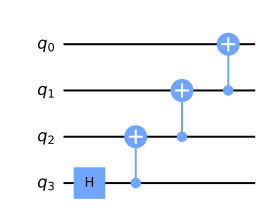

In [3]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(4)
qc.h(3)
qc.cx(3, 2)
qc.cx(2, 1)
qc.cx(1, 0)
qc.draw('mpl', filename='quantum_circuit.png')

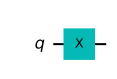

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.x(0)
qc.draw('mpl', filename='x.png')

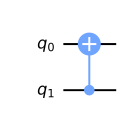

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.cx(1, 0)
qc.draw('mpl', filename='cx.png')

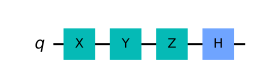

In [4]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.x(0)
qc.y(0)
qc.z(0)
qc.h(0)
qc.draw('mpl', filename='xyzh.png')

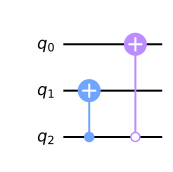

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)
qc.cx(2, 1)
qc.cx(2, 0, ctrl_state=0)
qc.draw('mpl', filename='cx0.png')

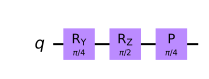

In [6]:
from qiskit import QuantumCircuit
import math

qc = QuantumCircuit(1)
qc.ry(math.pi/4, 0)
qc.rz(math.pi/2, 0)
qc.p(math.pi/4, 0)
qc.draw('mpl', filename='ry-rz-p.png')

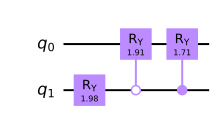

In [7]:
from qiskit import QuantumCircuit
import math

th0 = 2*math.atan2(math.sqrt(7), math.sqrt(3))
th10 = 2*math.atan2(math.sqrt(2), math.sqrt(1))
th11 = 2*math.atan2(math.sqrt(4), math.sqrt(3))

qc = QuantumCircuit(2)
qc.ry(th0, 1)
qc.cry(th10, 1, 0, ctrl_state='0')
qc.cry(th11, 1, 0)
qc.draw('mpl', filename='embed_example_circuit.png')

In [8]:
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer, AerSimulator
import math

th0 = 2*math.atan2(math.sqrt(7), math.sqrt(3))
th10 = 2*math.atan2(math.sqrt(2), math.sqrt(1))
th11 = 2*math.atan2(math.sqrt(4), math.sqrt(3))

qc = QuantumCircuit(2,2)
qc.ry(th0, 1)
qc.cry(th10, 1, 0, ctrl_state='0')
qc.cry(th11, 1, 0)
qc.measure([0,1], [0,1])
qc.draw('mpl', filename='embed_example_circuit_with_measure.png')

backend = Aer.get_backend('aer_simulator')
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc, shots=1000).result()
counts = result.get_counts()
plot_histogram(counts, filename='embed_example_histogram.png')


In [ ]:
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer, AerSimulator
import math

th0 = 2*math.atan2(math.sqrt(7), math.sqrt(3))
th10 = 2*math.atan2(math.sqrt(2), math.sqrt(1))
th11 = 2*math.atan2(math.sqrt(4), math.sqrt(3))

qc = QuantumCircuit(2)
qc.ry(th0, 1)
qc.cry(th10, 1, 0, ctrl_state='0')
qc.cry(th11, 1, 0)
qc.save_statevector("sv")
qc.draw('mpl', filename='embed_example_circuit_with_measure.png')

backend = Aer.get_backend('aer_simulator')
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc, shots=1000).result()
sv = result.data()['sv']
for i in range(len(sv)):
    print(f"sv[{i:02b}] = {sv[i]:f}, abs**2 = {abs(sv[i])**2:f}")

sv[00] = 0.316228+0.000000j, abs = 0.100000
sv[01] = 0.447214+0.000000j, abs = 0.200000
sv[10] = 0.547723+0.000000j, abs = 0.300000
sv[11] = 0.632456+0.000000j, abs = 0.400000


/tmp/ipykernel_12673/3542604808.py:22: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for i in range(len(sv)):


## cocary

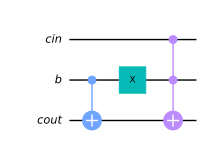

In [10]:
from qiskit import QuantumCircuit, QuantumRegister
import crsq_arithmetic.bit_ops as bb
import matplotlib.pyplot as plt

cin = QuantumRegister(1, "cin")  # carry in
b = QuantumRegister(1, "b")
cout = QuantumRegister(1, "cout")
qc = QuantumCircuit(cin, b, cout)
y=1
# hide internals
# qc.append(bb.cocarry_gate(y), [cin, b, cout])
# qc.barrier()
# show internals
bb.cocarry(qc, cin, y, b, cout)

fig,ax = plt.subplots(figsize=(3,2), layout='constrained')
filename='cocarry_diagram.png'
qc.draw(ax = ax)
fig.savefig(filename)


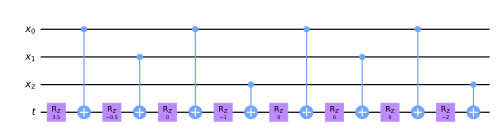

In [11]:
from crsq.blocks.gray_code_qrom import GrayCodeQrom
import numpy

alpha = numpy.array([0,1,2,3,4,5,6,7])

circ = GrayCodeQrom(3, alpha)

circ.circuit.draw(filename="ucrz-n3.png", scale=0.6)